# Advanced Performance Models - Comparison & Analysis
## Testing Multiple Algorithms and Comparing Results

## Section 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

# Load cleaned and reordered data
df = pd.read_csv('../Final Dataset/cleaned_player_data_performance_model_reordered.csv')

print("\nData loaded: {} rows x {} columns".format(df.shape[0], df.shape[1]))

print("\nDataset Overview:")
print("  Shape: {}".format(df.shape))
print("  Columns: {}".format(', '.join(df.columns.tolist())))

print("\nData Quality Check:")
print("  Missing values: {}".format(df.isnull().sum().sum()))
print("  Data types: All numeric (ready for model training)")


All libraries imported successfully!

Data loaded: 8714 rows x 12 columns

Dataset Overview:
  Shape: (8714, 12)
  Columns: potential, ball_control, dribbling, stamina, reactions, balance, strength, acceleration, age, attacking_work_rate_encoded, defensive_work_rate_encoded, overall_rating

Data Quality Check:
  Missing values: 0
  Data types: All numeric (ready for model training)


## Section 2: Data Preparation & Feature Selection

In [2]:
# Prepare features and target
target = 'overall_rating'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Select important features based on correlation
correlations = df[numeric_cols].corr()[target].drop(target).sort_values(ascending=False)
important_features = correlations[correlations.abs() > 0.1].index.tolist()

X = df[important_features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 80)
print("DATA PREPARATION SUMMARY")
print("=" * 80)

print("\nFeatures selected: {}".format(len(important_features)))
print("   Features: {}".format(', '.join(important_features)))

print("\nDataset Split:")
print("   Training set: {:,} samples".format(len(X_train)))
print("   Testing set:  {:,} samples".format(len(X_test)))

print("\nFeature Scaling: StandardScaler applied")


DATA PREPARATION SUMMARY

Features selected: 10
   Features: potential, reactions, ball_control, dribbling, stamina, strength, acceleration, balance, defensive_work_rate_encoded, attacking_work_rate_encoded

Dataset Split:
   Training set: 6,971 samples
   Testing set:  1,743 samples

Feature Scaling: StandardScaler applied


## Section 3: Train Multiple Advanced Models

In [3]:
# Define models to compare
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'SVR_RBF': SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.2),
    'XGBoost': XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
}

results = []

print("=" * 80)
print("TRAINING ADVANCED MODELS")
print("=" * 80)

for name, model in models.items():
    print("\nTraining model: {}".format(name))
    
    if name in ['LinearRegression', 'SVR_RBF', 'XGBoost']:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
    
    model.fit(X_tr, y_train)
    
    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_ev = explained_variance_score(y_test, y_test_pred)
    
    results.append({
        'Model': name,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Explained_Variance': test_ev,
        'Overfit_Diff': abs(train_r2 - test_r2)
    })
    
    print("   Done. Test R²: {:.4f}, RMSE: {:.4f}, MAE: {:.4f}".format(test_r2, test_rmse, test_mae))

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("MODEL COMPARISON TABLE")
print("=" * 80)

print(results_df.to_string(index=False))


TRAINING ADVANCED MODELS

Training model: LinearRegression
   Done. Test R²: 0.8388, RMSE: 2.3956, MAE: 1.8549

Training model: RandomForest
   Done. Test R²: 0.8908, RMSE: 1.9718, MAE: 1.4576

Training model: GradientBoosting
   Done. Test R²: 0.8841, RMSE: 2.0309, MAE: 1.5358

Training model: SVR_RBF
   Done. Test R²: 0.8907, RMSE: 1.9723, MAE: 1.4402

Training model: XGBoost
   Done. Test R²: 0.8917, RMSE: 1.9632, MAE: 1.4592

MODEL COMPARISON TABLE
           Model  Train_R2  Test_R2  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Explained_Variance  Overfit_Diff
LinearRegression  0.843044 0.838759    2.350552   2.395559   1.821936  1.854920            0.838981      0.004285
    RandomForest  0.984746 0.890759    0.732777   1.971800   0.536194  1.457625            0.891145      0.093987
GradientBoosting  0.898342 0.884107    1.891696   2.030940   1.428981  1.535807            0.884210      0.014235
         SVR_RBF  0.915447 0.890698    1.725224   1.972343   1.178206  1.440196        

## Section 4: Visual Comparison of Model Performance

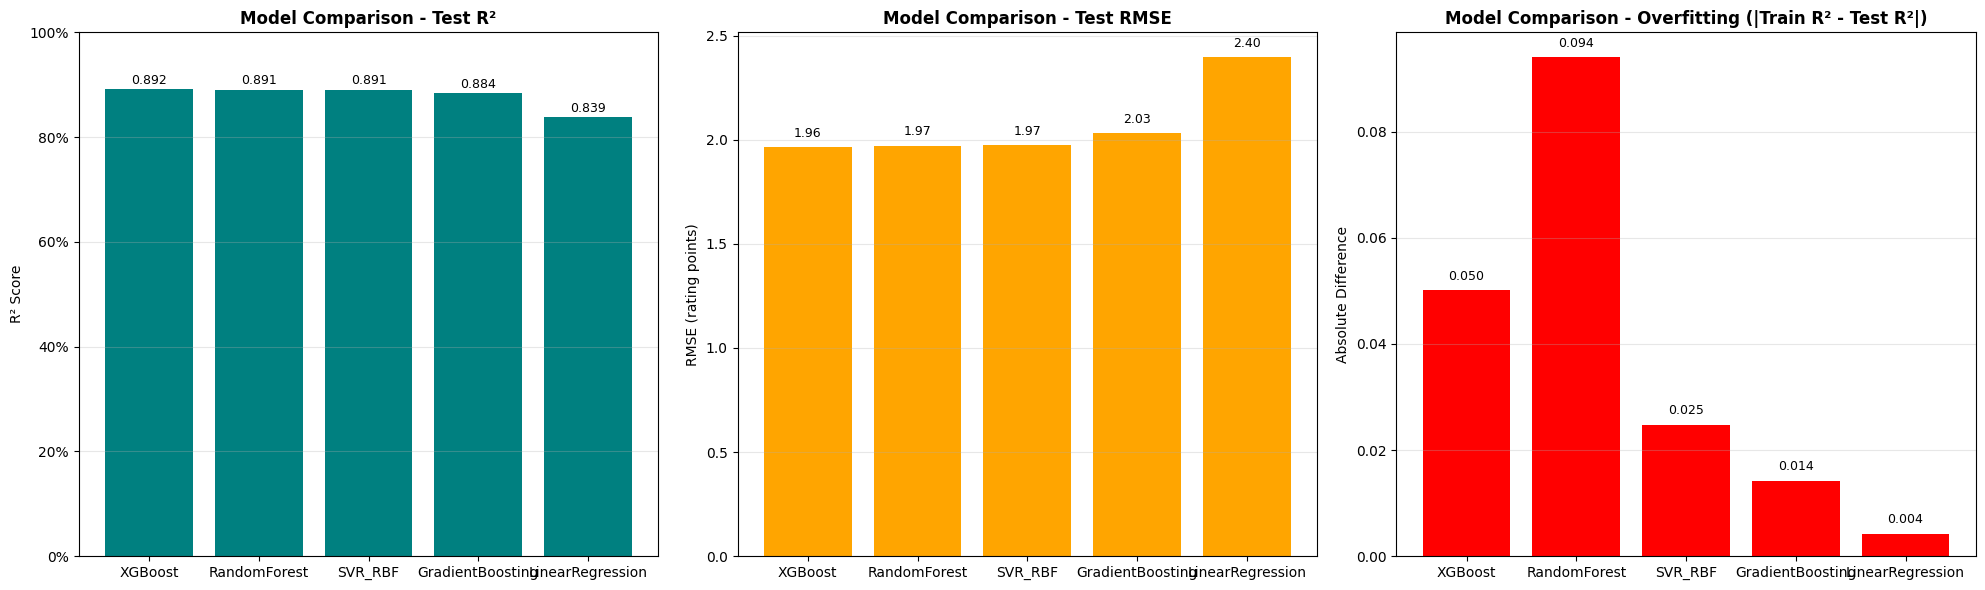

✅ Visual comparison of models created!


In [4]:
import matplotlib.ticker as mtick

# Sort by Test R2
results_sorted = results_df.sort_values('Test_R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Test R²
axes[0].bar(results_sorted['Model'], results_sorted['Test_R2'], color='teal')
axes[0].set_title('Model Comparison - Test R²', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for i, v in enumerate(results_sorted['Test_R2']):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

# 2. Test RMSE
axes[1].bar(results_sorted['Model'], results_sorted['Test_RMSE'], color='orange')
axes[1].set_title('Model Comparison - Test RMSE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE (rating points)')
for i, v in enumerate(results_sorted['Test_RMSE']):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)

# 3. Overfitting Difference (Train R² - Test R²)
axes[2].bar(results_sorted['Model'], results_sorted['Overfit_Diff'], color='red')
axes[2].set_title('Model Comparison - Overfitting (|Train R² - Test R²|)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Absolute Difference')
for i, v in enumerate(results_sorted['Overfit_Diff']):
    axes[2].text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=9)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visual comparison of models created!")


## Section 5: Final Summary & Best Model Selection

In [5]:
print("\n" + "=" * 100)
print("ADVANCED MODEL COMPARISON - FINAL SUMMARY")
print("=" * 100)

# Sort by Test R2 (best first)
results_sorted = results_df.sort_values('Test_R2', ascending=False)

print("\nMODEL PERFORMANCE OVERVIEW (sorted by Test R²):\n")
print(results_sorted.to_string(index=False, 
                               formatters={
                                   'Train_R2': lambda x: f"{x:.4f}",
                                   'Test_R2': lambda x: f"{x:.4f}",
                                   'Train_RMSE': lambda x: f"{x:.4f}",
                                   'Test_RMSE': lambda x: f"{x:.4f}",
                                   'Train_MAE': lambda x: f"{x:.4f}",
                                   'Test_MAE': lambda x: f"{x:.4f}",
                                   'Explained_Variance': lambda x: f"{x:.4f}",
                                   'Overfit_Diff': lambda x: f"{x:.4f}"
                               }))

best_row = results_sorted.iloc[0]

print("\n" + "-" * 100)
print("BEST PERFORMING MODEL:")
print("-" * 100)

print("   Model:               {}".format(best_row['Model']))
print("   Test R²:             {:.4f} ({:.2f}% variance explained)".format(best_row['Test_R2'], best_row['Test_R2']*100))
print("   Test RMSE:           {:.4f} rating points".format(best_row['Test_RMSE']))
print("   Test MAE:            {:.4f} rating points".format(best_row['Test_MAE']))
print("   Overfitting Diff:    {:.4f}".format(best_row['Overfit_Diff']))

print("\nBASELINE VS BEST MODEL (Test R² and RMSE):")
baseline_row = results_sorted[results_sorted['Model'] == 'LinearRegression'].iloc[0]

print("   Baseline (LinearRegression) -> R²: {:.4f}, RMSE: {:.4f}".format(baseline_row['Test_R2'], baseline_row['Test_RMSE']))
print("   Best ({}) -> R²: {:.4f}, RMSE: {:.4f}".format(best_row['Model'], best_row['Test_R2'], best_row['Test_RMSE']))

improvement_r2 = best_row['Test_R2'] - baseline_row['Test_R2']
improvement_rmse = baseline_row['Test_RMSE'] - best_row['Test_RMSE']

print("\nIMPROVEMENT OVER BASELINE:")
print("   Delta R²:             {:.4f} ({:.2f}% additional variance explained)".format(improvement_r2, improvement_r2*100))
print("   Delta RMSE:           {:.4f} rating points less error".format(improvement_rmse))

print("\nINTERPRETATION:")
if improvement_r2 > 0.02:
    print("   Advanced model clearly outperforms baseline")
elif improvement_r2 > 0.005:
    print("   Advanced model is slightly better than baseline")
else:
    print("   Advanced models provide marginal or no improvement over baseline")

print("   Choose model based on performance and complexity trade-off")

print("\n" + "=" * 100)



ADVANCED MODEL COMPARISON - FINAL SUMMARY

MODEL PERFORMANCE OVERVIEW (sorted by Test R²):

           Model Train_R2 Test_R2 Train_RMSE Test_RMSE Train_MAE Test_MAE Explained_Variance Overfit_Diff
         XGBoost   0.9418  0.8917     1.4313    1.9632    1.0585   1.4592             0.8917       0.0501
    RandomForest   0.9847  0.8908     0.7328    1.9718    0.5362   1.4576             0.8911       0.0940
         SVR_RBF   0.9154  0.8907     1.7252    1.9723    1.1782   1.4402             0.8913       0.0247
GradientBoosting   0.8983  0.8841     1.8917    2.0309    1.4290   1.5358             0.8842       0.0142
LinearRegression   0.8430  0.8388     2.3506    2.3956    1.8219   1.8549             0.8390       0.0043

----------------------------------------------------------------------------------------------------
BEST PERFORMING MODEL:
----------------------------------------------------------------------------------------------------
   Model:               XGBoost
   Test R²:  